In [104]:
#imports
import warnings
warnings.simplefilter("ignore")
from imblearn.over_sampling import SMOTE
import sys
import os
sys.path.append(os.path.abspath(".."))
from clean.preprocessing import DataPreprocessor
import joblib
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score


In [105]:
df=pd.read_csv("../data/heart_disease_uci.csv")
CAT=['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in CAT:
    print(f"\n {col, df[col].unique()}\n")
# print(f"\n {col, df[col].unique()}\n")
#print(df.head()) #print the first five rows
#print(df.duplicated().sum()) # check duplicated rows
df.drop(columns=["id"], inplace=True) # drop the id column
#print(df.head()) # print to check whether id have been dropped
df["Heart Disease"] = df["num"].apply(lambda x: 1 if x > 0 else 0) # convert the num column to binary then rename it to Heart Disease
df.drop(columns=["num"],inplace=True) #Drop num column to avoid duplicate
#print(df["Heart Disease"]) # print heart disease to check whether it have been converted to binary
df['trestbps']=df['trestbps'].replace(0, np.nan) # Reason for filling values 0 with nan is because in real life it is impossible for a patient to have blood pressure zero
df['chol']=df['chol'].replace(0, np.nan)
print((df['chol']==0) .sum())
#df.drop(columns=["sex"], inplace=True)
X=df.drop(columns=["Heart Disease"])
y=df["Heart Disease"]
#print(X)
#print(y)
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42,shuffle=True)
cols_to_fix = ['thal', 'restecg', 'chol', 'trestbps']
train_stats = X_train.groupby('dataset')[cols_to_fix].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.mean())
for col in cols_to_fix:
    X_train[col] = X_train[col].fillna(X_train['dataset'].map(train_stats[col]))
    X_test[col] = X_test[col].fillna(X_test['dataset'].map(train_stats[col]))


# 2. Map these values to both train and test sets
# This ensures X_test only ever uses knowledge derived from X_train
for col in cols_to_fix:
    X_train[col] = X_train[col].fillna(X_train['dataset'].map(train_stats[col]))
    X_test[col] = X_test[col].fillna(X_test['dataset'].map(train_stats[col]))

X_train = X_train.drop(columns=["dataset"])
X_test = X_test.drop(columns=["dataset"])
#print(X_train)
#print(X_test)
#print(X_train.isnull().sum())
#print(y_train.isnull().sum())
numerical_cols=X_train.select_dtypes(include="number").columns.tolist()
categorical_cols=X_train.select_dtypes(exclude="number").columns.tolist()
#print(numerical_cols)
#print(categorical_cols)

strategies=DataPreprocessor(
    fill_strategies={
        'trestbps':"median",
        'chol': "median", 
        'thalch':"median", 
        'oldpeak':"median", 
        'ca': "median",

        'cp' :"mode",
        'fbs':"mode" ,
        'restecg':"mode",
        'exang': "mode", 
        'slope': "unknown",
        'thal' : "unknown",
    },

    encoding_strategies={
        'sex': "onehot" ,
        'dataset': "onehot",
        "cp":"onehot",
        "fbs":"onehot",
        "restecg":"onehot",
        "exang":"onehot",
        'slope':"onehot" ,
        'thal' :"onehot" ,

    }
)
strategies.fit(X_train)
X_train=strategies.transform(X_train)
X_test=strategies.transform(X_test)




 ('sex', array(['Male', 'Female'], dtype=object))


 ('dataset', array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object))


 ('cp', array(['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina'],
      dtype=object))


 ('fbs', array([True, False, nan], dtype=object))


 ('restecg', array(['lv hypertrophy', 'normal', 'st-t abnormality', nan], dtype=object))


 ('exang', array([False, True, nan], dtype=object))


 ('slope', array(['downsloping', 'flat', 'upsloping', nan], dtype=object))


 ('thal', array(['fixed defect', 'normal', 'reversable defect', nan], dtype=object))

0


In [106]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())
print(X_train.head())
print(X_train.dtypes)
#print(X_train.isnull().sum())
print(X_test.isnull().sum().sum())
print(df.shape)



age                         0
trestbps                    0
chol                        0
thalch                      0
oldpeak                     0
ca                          0
sex_Female                  0
sex_Male                    0
cp_asymptomatic             0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
fbs_False                   0
fbs_True                    0
fbs_nan                     0
restecg_lv hypertrophy      0
restecg_normal              0
restecg_st-t abnormality    0
exang_False                 0
exang_True                  0
exang_nan                   0
slope_downsloping           0
slope_flat                  0
slope_upsloping             0
slope_nan                   0
thal_fixed defect           0
thal_normal                 0
thal_reversable defect      0
dtype: int64
age                         0
trestbps                    0
chol                        0
thalch                      0
oldpeak                    

In [107]:
rf_model = RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42)
lr_model = LogisticRegression(class_weight='balanced',max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Run Cross-Validation
# This returns an array of 5 accuracy scores
rf_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='accuracy')
lr_scores = cross_val_score(lr_model, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Random Forest Mean Accuracy: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
print(f"Logistic Regression Mean Accuracy: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")
lr_model.fit(X_train, y_train)


joblib.dump(lr_model, "heart_disease_predictor.pkl")
joblib.dump(strategies, "strategies.pkl")
print("Bravo! Model and Preprocessor saved successfully")




Random Forest Mean Accuracy: 0.7976 (+/- 0.0214)
Logistic Regression Mean Accuracy: 0.8003 (+/- 0.0158)
Bravo! Model and Preprocessor saved successfully


<Axes: xlabel='trestbps', ylabel='Count'>

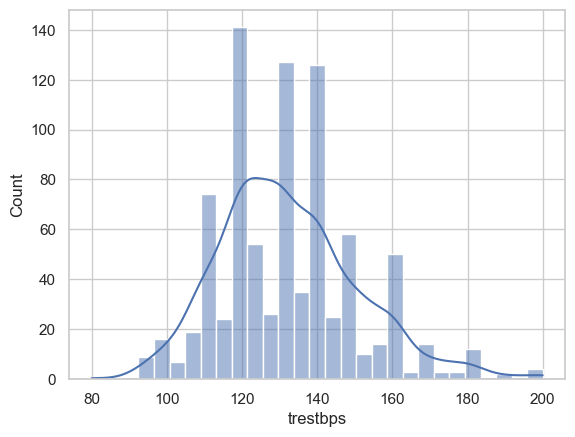

In [108]:
#['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
#['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
df.isnull().sum()
import seaborn as sns
sns.histplot(df['trestbps'], kde=True)

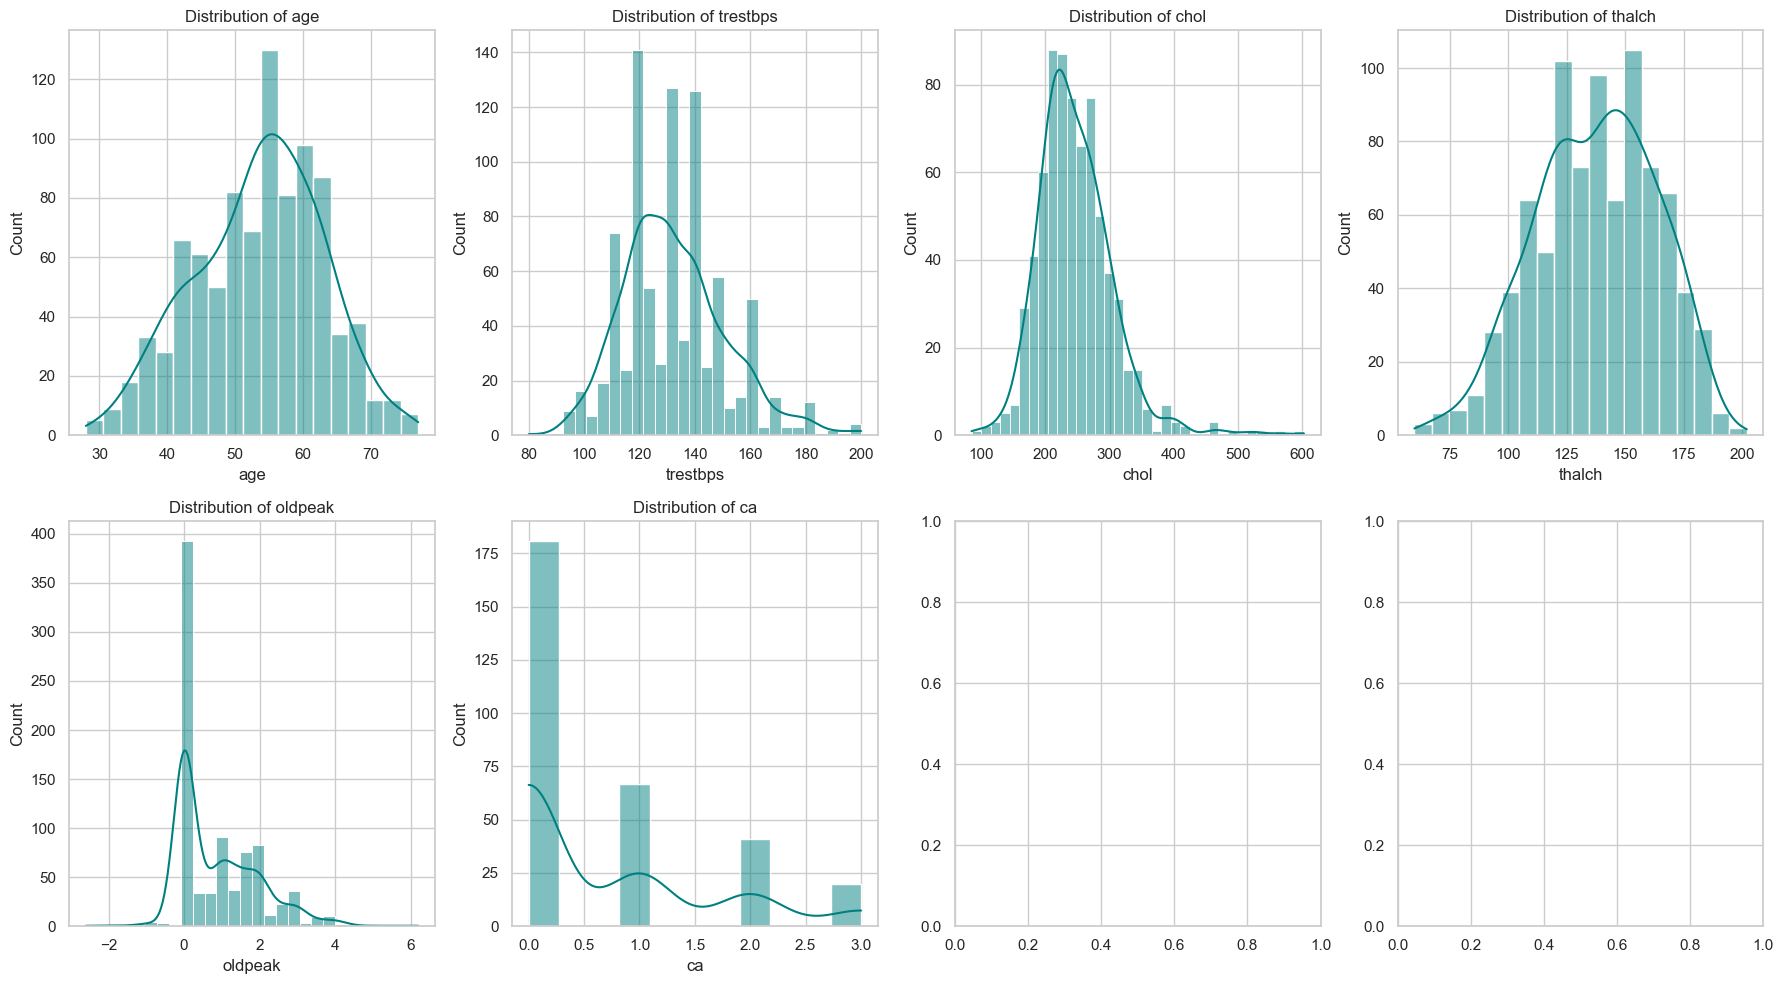

In [109]:
#plotting to understand the data

sns.set_theme(style="whitegrid")
fig,axes=plt.subplots(nrows=2, ncols=4, figsize=(18,10))
axes=axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="teal")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

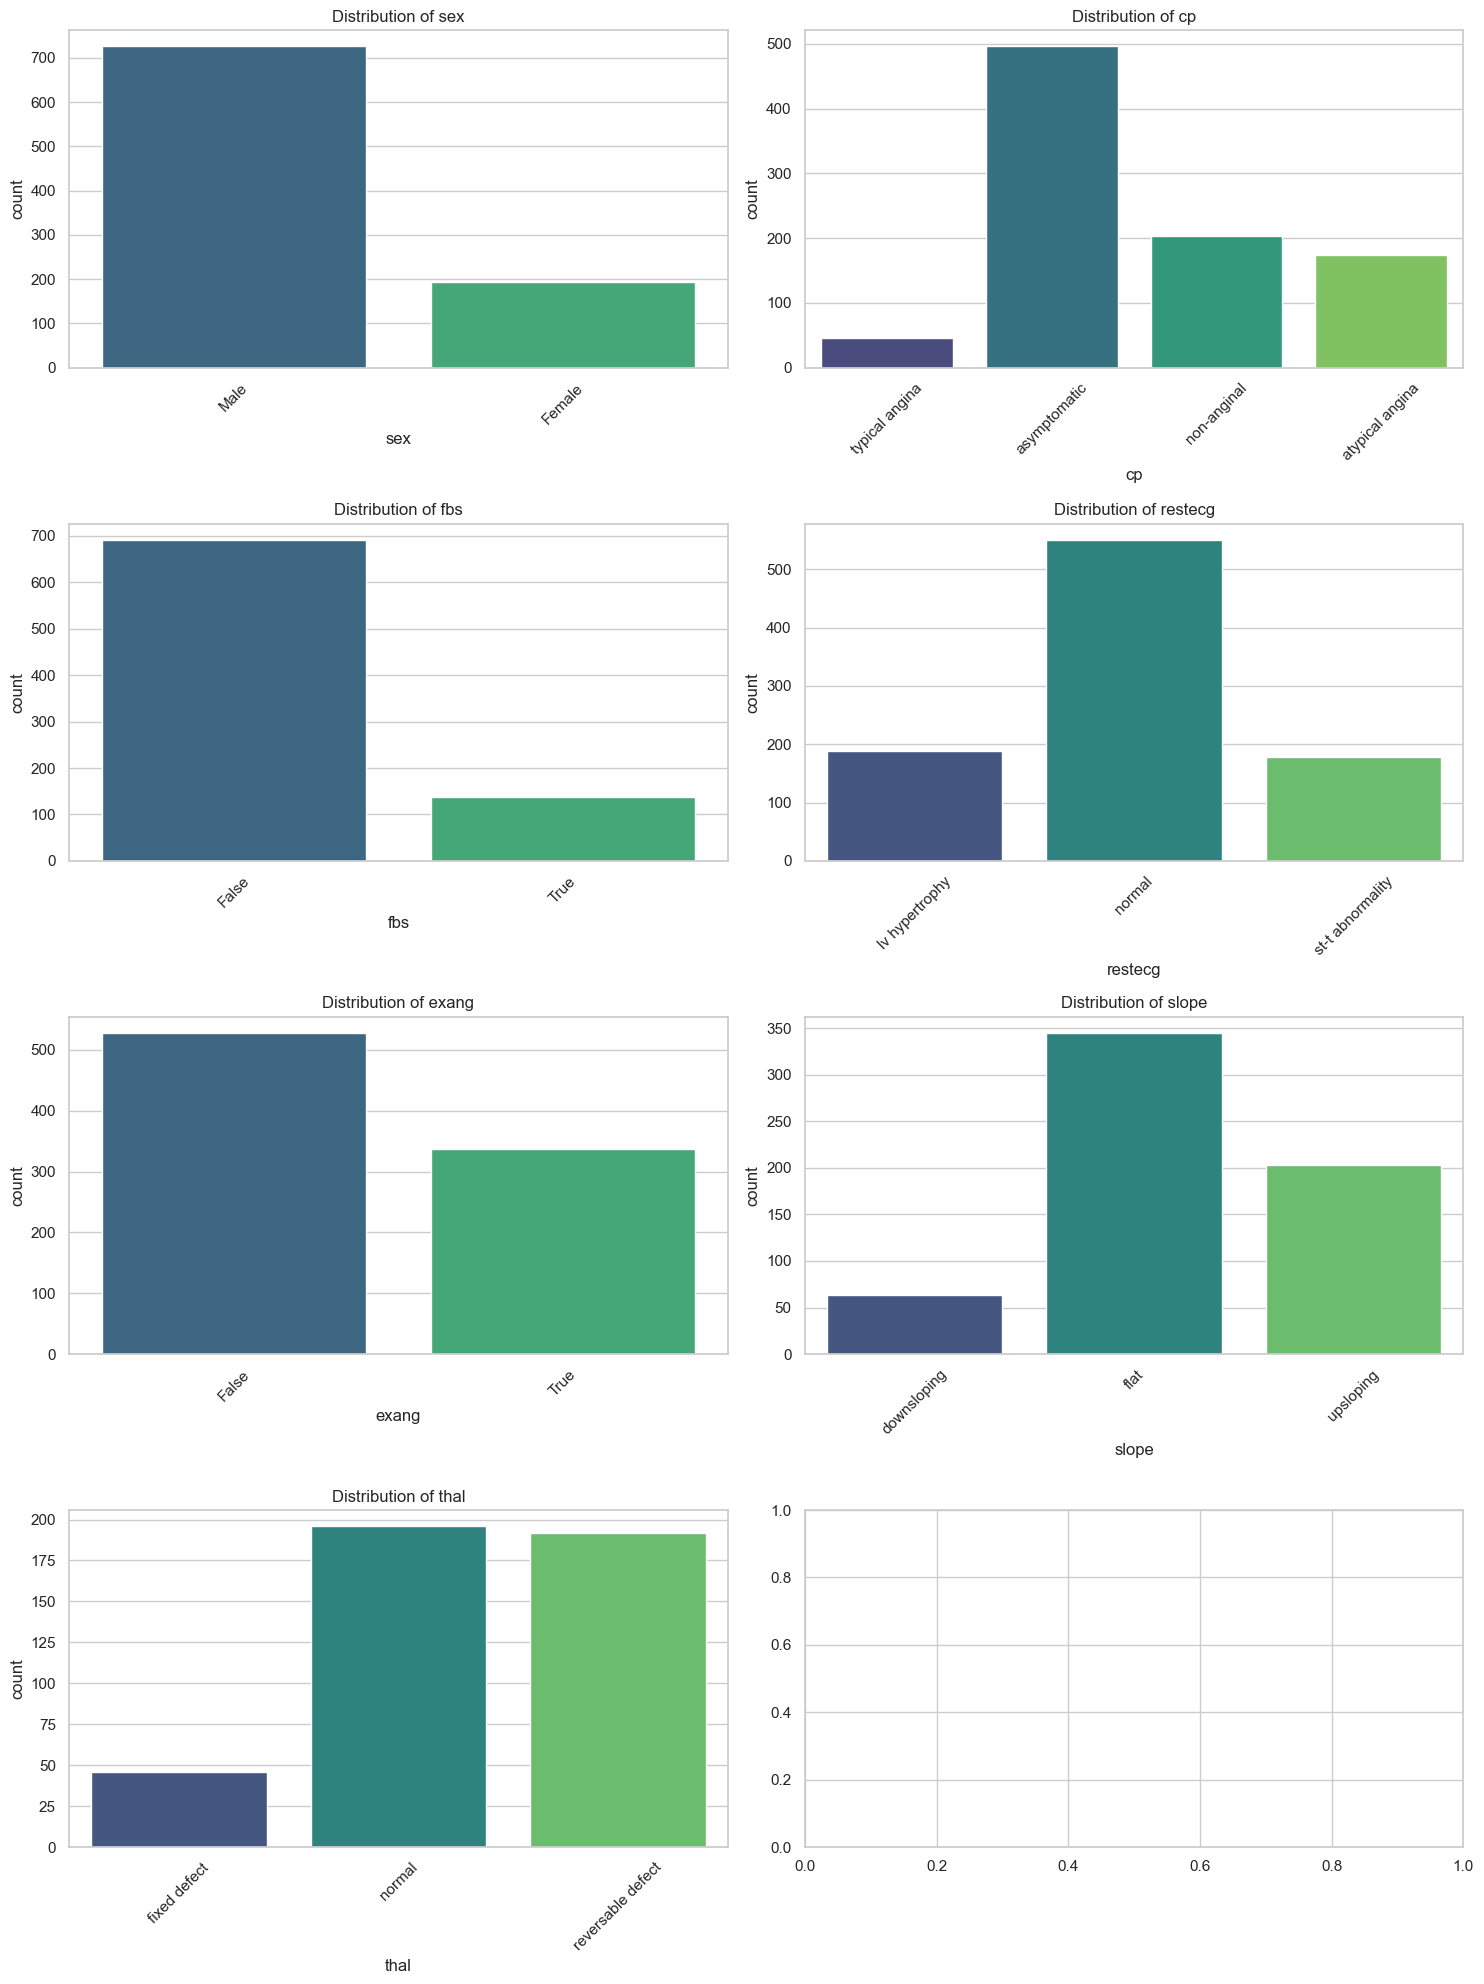

In [110]:
fig,axes=plt.subplots(nrows=4, ncols=2, figsize=(15,20))
axes=axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df,x=col, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [111]:
cols_to_check = ['thal', 'restecg', 'chol', 'trestbps']

# Create a boolean dataframe where True means 'is missing'
missing_df = df[cols_to_check].isnull()

# Add the 'dataset' column back so we can group by it
missing_df['dataset'] = df['dataset']

# Now group by the dataset and count the missing values
systematic_check = missing_df.groupby('dataset').sum()

print(systematic_check)

               thal  restecg  chol  trestbps
dataset                                     
Cleveland         3        0     0         0
Hungary         265        1    23         1
Switzerland      52        1   123         2
VA Long Beach   166        0    56        57


In [112]:
print(numerical_cols)
print(categorical_cols)

['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
